# Credit Card Fraud Detection
## 03 - Baseline Machine Learning Models

### Objective

In this notebook, we train and evaluate baseline machine learning
models for fraudulent transaction detection.

The models used are:

1. Logistic Regression
2. Decision Tree
3. Random Forest
4. K-Nearest Neighbors
5. Support Vector Machine
6. Naive Bayes

The training data has already been standardized and balanced using
random undersampling.

The test set remains untouched and retains its original class
distribution.

### Evaluation Metrics

We will evaluate the models using:

- Accuracy
- Precision
- Recall
- F1-score
- ROC-AUC
- Confusion Matrix
- ROC Curve

In [36]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.naive_bayes import GaussianNB

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
     average_precision_score,
      precision_recall_curve,
    confusion_matrix,
    classification_report,
    RocCurveDisplay,
    precision_recall_curve
)

import warnings
warnings.filterwarnings("ignore")

In [37]:
import pandas as pd

X_train_balanced = pd.read_csv("processed/X_train_balanced.csv")
y_train_balanced = pd.read_csv("processed/y_train_balanced.csv").squeeze()

X_test_scaled = pd.read_csv("processed/X_test_scaled.csv")
y_test = pd.read_csv("processed/y_test.csv").squeeze()

print("Training:", X_train_balanced.shape)
print("Testing :", X_test_scaled.shape)

print("\nTraining classes:")
print(y_train_balanced.value_counts())

print("\nTesting classes:")
print(y_test.value_counts())

Training: (788, 30)
Testing : (56962, 30)

Training classes:
Class
0    394
1    394
Name: count, dtype: int64

Testing classes:
Class
0    56864
1       98
Name: count, dtype: int64


In [38]:
models = {
    "Logistic Regression": LogisticRegression(
        max_iter=1000,
        random_state=42
    ),

    "Decision Tree": DecisionTreeClassifier(
        random_state=42
    ),

    "Random Forest": RandomForestClassifier(
        n_estimators=100,
        random_state=42,
        n_jobs=-1
    ),

    "K-Nearest Neighbors": KNeighborsClassifier(
        n_neighbors=5
    ),

    "Support Vector Machine": SVC(
        probability=True,
        random_state=42
    ),

    "Naive Bayes": GaussianNB()
}

In [40]:
lr = models["Logistic Regression"]

lr.fit(
    X_train_balanced,
    y_train_balanced
)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,42
,solver,'lbfgs'
,max_iter,1000
,multi_class,'deprecated'


In [41]:
y_pred_lr = lr.predict(X_test_scaled)

y_prob_lr = lr.predict_proba(
    X_test_scaled
)[:, 1]

In [42]:
print(classification_report(
    y_test,
    y_pred_lr
))

              precision    recall  f1-score   support

           0       1.00      0.96      0.98     56864
           1       0.04      0.92      0.07        98

    accuracy                           0.96     56962
   macro avg       0.52      0.94      0.53     56962
weighted avg       1.00      0.96      0.98     56962



In [43]:
lr_auc = roc_auc_score(
    y_test,
    y_prob_lr
)
lr_precision, lr_recall, lr_thresholds = precision_recall_curve(
    y_test,
    y_prob_lr
)

lr_pr_auc = average_precision_score(
    y_test,
    y_prob_lr
)
print("Logistic Regression ROC-AUC:", lr_auc)
print("Logistic Regression PR-AUC:", lr_pr_auc)

Logistic Regression ROC-AUC: 0.9761259948548918
Logistic Regression PR-AUC: 0.656263161634427


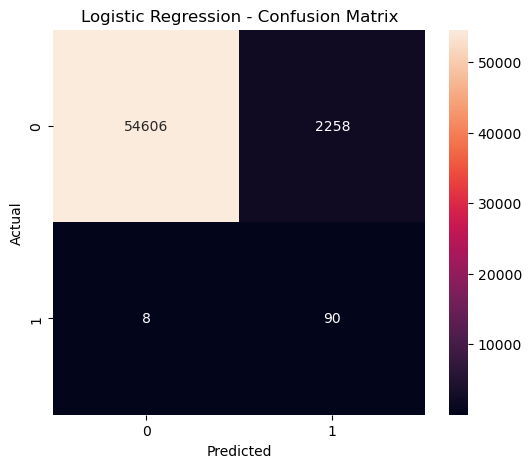

In [44]:
cm = confusion_matrix(
    y_test,
    y_pred_lr
)

plt.figure(figsize=(6, 5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d"
)

plt.title("Logistic Regression - Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

In [45]:
from sklearn.metrics import average_precision_score

results = []

trained_models = {}

for name, model in models.items():

    print(f"Training {name}...")

    model.fit(
        X_train_balanced,
        y_train_balanced
    )

    trained_models[name] = model

    y_pred = model.predict(X_test_scaled)

    if hasattr(model, "predict_proba"):
        y_prob = model.predict_proba(
            X_test_scaled
        )[:, 1]

    else:
        y_prob = model.decision_function(
            X_test_scaled
        )

    # Precision-Recall AUC
    pr_auc = average_precision_score(
        y_test,
        y_prob
    )

    results.append({
        "Model": name,

        "Accuracy": accuracy_score(
            y_test,
            y_pred
        ),

        "Precision": precision_score(
            y_test,
            y_pred,
            zero_division=0
        ),

        "Recall": recall_score(
            y_test,
            y_pred,
            zero_division=0
        ),

        "F1": f1_score(
            y_test,
            y_pred,
            zero_division=0
        ),

        "ROC-AUC": roc_auc_score(
            y_test,
            y_prob
        ),

        "PR-AUC": pr_auc
    })

print("Training completed.")

Training Logistic Regression...
Training Decision Tree...
Training Random Forest...
Training K-Nearest Neighbors...
Training Support Vector Machine...
Training Naive Bayes...
Training completed.


In [48]:
results_df = pd.DataFrame(results)

results_df

,Model,Accuracy,Precision,Recall,F1,ROC-AUC,PR-AUC
0,Logistic Regression,0.960219,0.038330,0.918367,0.073590,0.976126,0.656263
1,Decision Tree,0.903286,0.015924,0.908163,0.031299,0.905721,0.014620
2,Random Forest,0.964116,0.042333,0.918367,0.080935,0.977697,0.695286
3,K-Nearest Neighbors,0.972701,0.053889,0.897959,0.101675,0.963197,0.200196
4,Support Vector Machine,0.981058,0.075325,0.887755,0.138867,0.979027,0.599726
5,Naive Bayes,0.960869,0.037343,0.877551,0.071637,0.958773,0.054649


In [29]:
results_df.sort_values(
    by="ROC-AUC",
    ascending=False
).round(4)

,Model,Accuracy,Precision,Recall,F1,ROC-AUC,PR-AUC
4,Support Vector Machine,0.9811,0.0753,0.8878,0.1389,0.9790,0.5997
2,Random Forest,0.9641,0.0423,0.9184,0.0809,0.9777,0.6953
0,Logistic Regression,0.9602,0.0383,0.9184,0.0736,0.9761,0.6563
3,K-Nearest Neighbors,0.9727,0.0539,0.8980,0.1017,0.9632,0.2002
5,Naive Bayes,0.9609,0.0373,0.8776,0.0716,0.9588,0.0546
1,Decision Tree,0.9033,0.0159,0.9082,0.0313,0.9057,0.0146


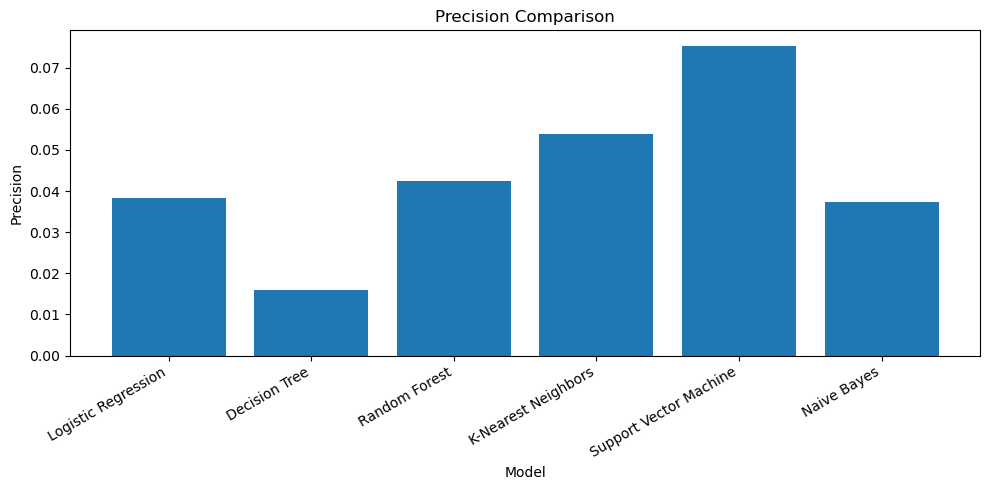

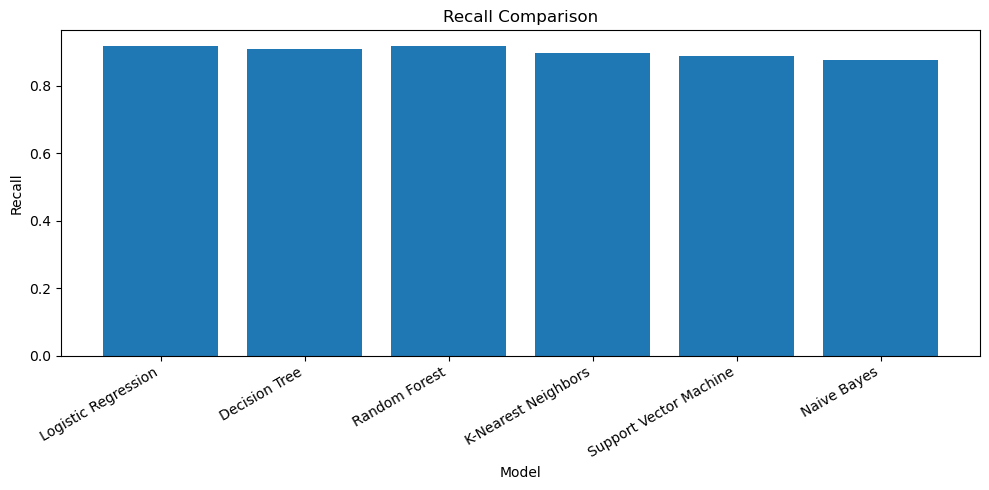

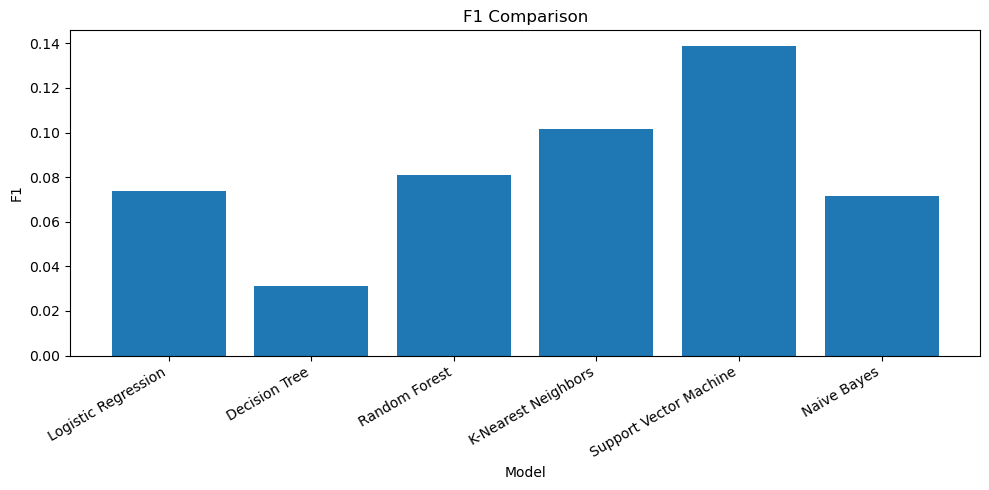

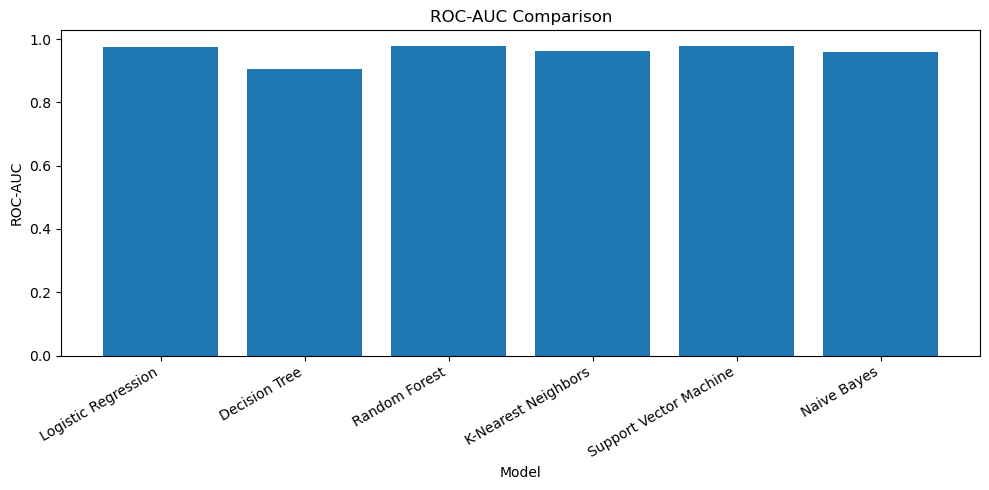

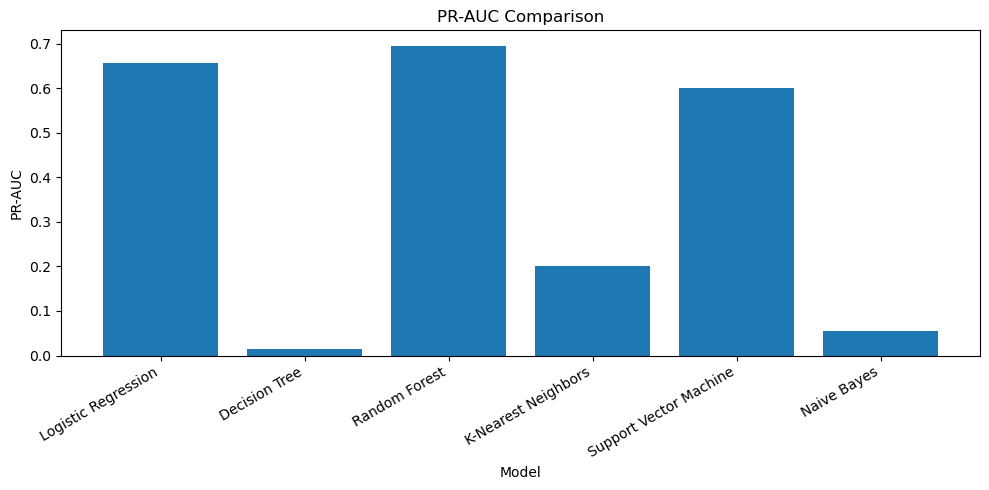

In [49]:
metrics = [
    "Precision",
    "Recall",
    "F1",
    "ROC-AUC",
    "PR-AUC"
]

for metric in metrics:

    plt.figure(figsize=(10, 5))

    plt.bar(
        results_df["Model"],
        results_df[metric]
    )

    plt.title(f"{metric} Comparison")
    plt.xlabel("Model")
    plt.ylabel(metric)

    plt.xticks(
        rotation=30,
        ha="right"
    )

    plt.tight_layout()
    plt.show()

<Figure size 1000x700 with 0 Axes>

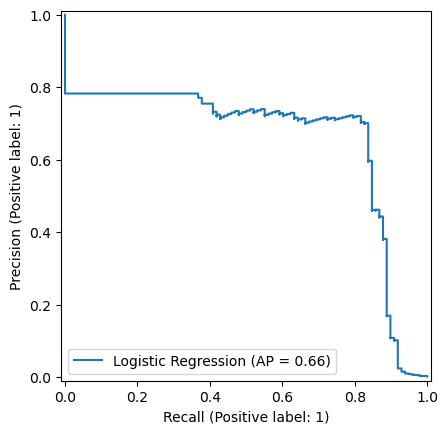

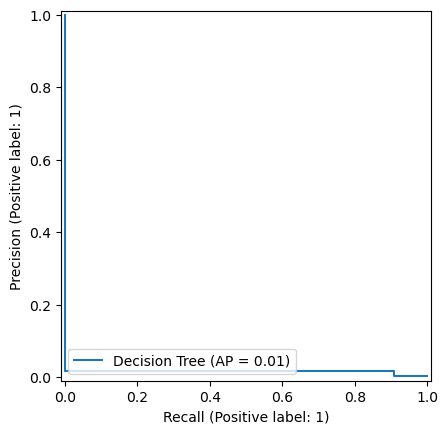

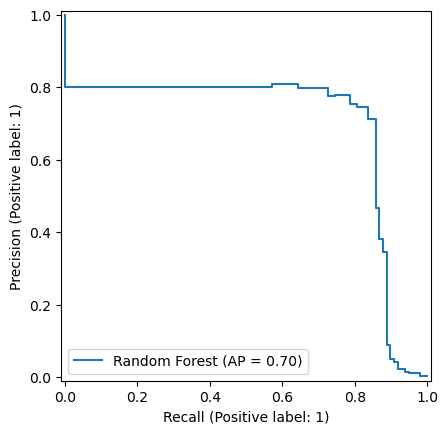

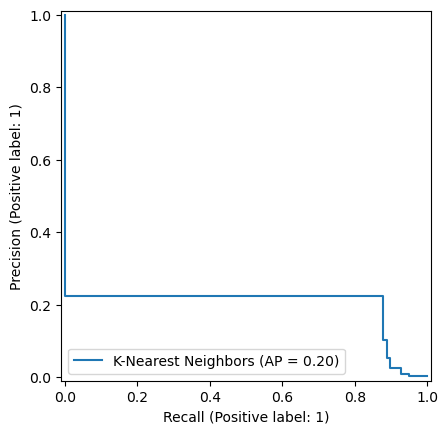

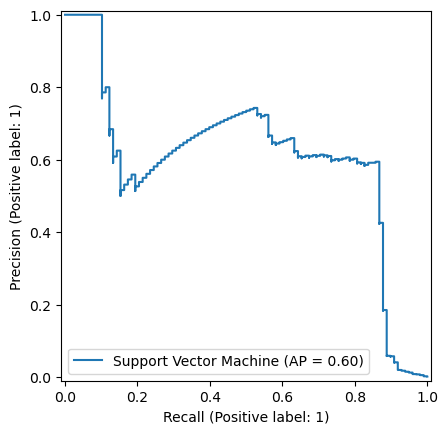

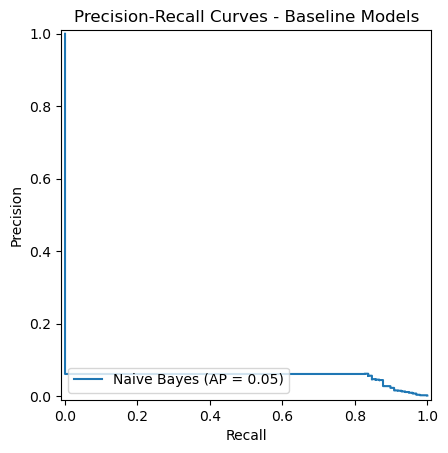

In [ ]:
plt.figure(figsize=(10, 7))

for name, model in trained_models.items():

    if hasattr(model, "predict_proba"):
        y_prob = model.predict_proba(
            X_test_scaled
        )[:, 1]

    else:
        y_prob = model.decision_function(
            X_test_scaled
        )

    RocCurveDisplay.from_predictions(
        y_test,
        y_prob,
        name=name
    )

plt.title("ROC Curves - Baseline Models")
plt.show()

<Figure size 1000x700 with 0 Axes>

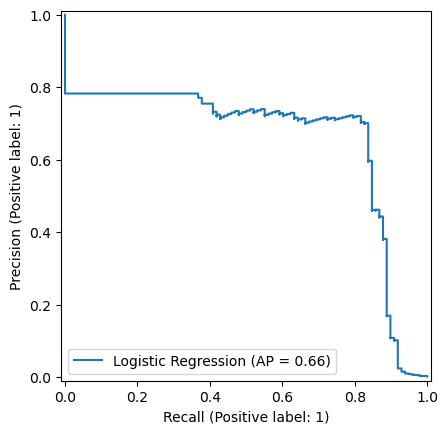

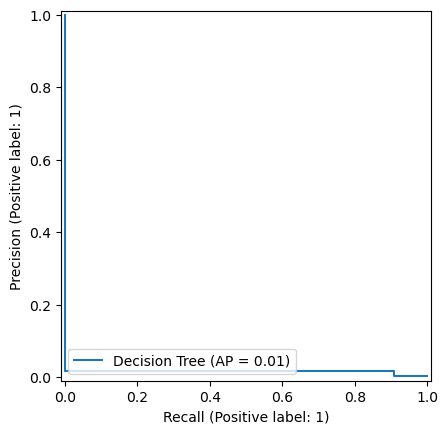

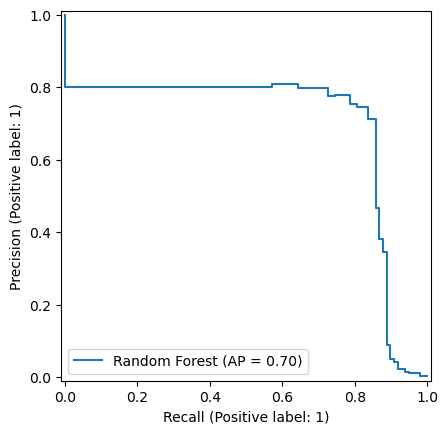

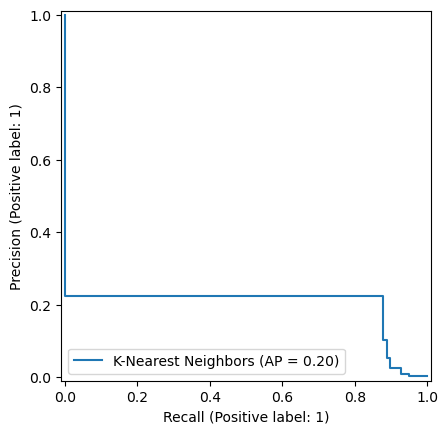

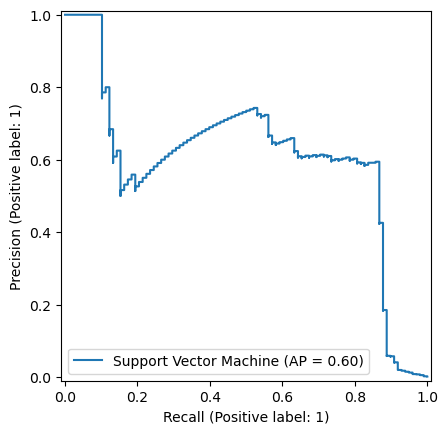

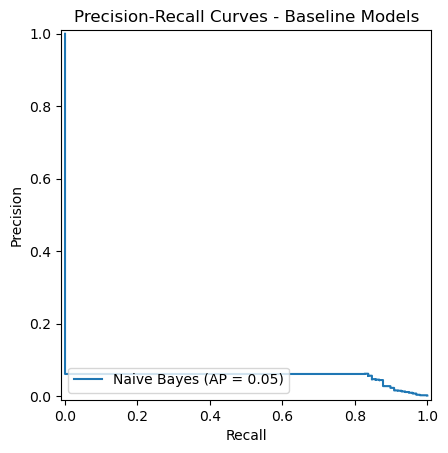

In [51]:
from sklearn.metrics import PrecisionRecallDisplay

plt.figure(figsize=(10, 7))

for name, model in trained_models.items():

    if hasattr(model, "predict_proba"):
        y_prob = model.predict_proba(
            X_test_scaled
        )[:, 1]

    else:
        y_prob = model.decision_function(
            X_test_scaled
        )

    PrecisionRecallDisplay.from_predictions(
        y_test,
        y_prob,
        name=name
    )

plt.title("Precision-Recall Curves - Baseline Models")
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.show()

In [52]:
for name, model in trained_models.items():

    y_pred = model.predict(
        X_test_scaled
    )

    print("=" * 70)
    print(name)
    print("=" * 70)

    print(
        classification_report(
            y_test,
            y_pred,
            target_names=[
                "Genuine",
                "Fraud"
            ],
            zero_division=0
        )
    )

Logistic Regression
              precision    recall  f1-score   support

     Genuine       1.00      0.96      0.98     56864
       Fraud       0.04      0.92      0.07        98

    accuracy                           0.96     56962
   macro avg       0.52      0.94      0.53     56962
weighted avg       1.00      0.96      0.98     56962

Decision Tree
              precision    recall  f1-score   support

     Genuine       1.00      0.90      0.95     56864
       Fraud       0.02      0.91      0.03        98

    accuracy                           0.90     56962
   macro avg       0.51      0.91      0.49     56962
weighted avg       1.00      0.90      0.95     56962

Random Forest
              precision    recall  f1-score   support

     Genuine       1.00      0.96      0.98     56864
       Fraud       0.04      0.92      0.08        98

    accuracy                           0.96     56962
   macro avg       0.52      0.94      0.53     56962
weighted avg       1.00   

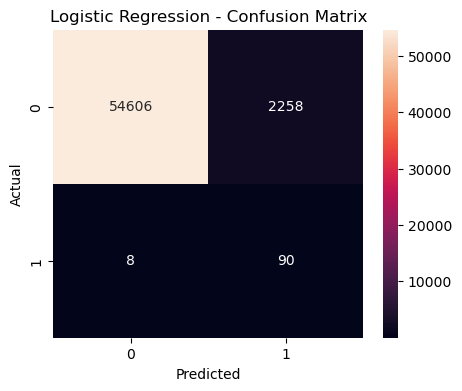

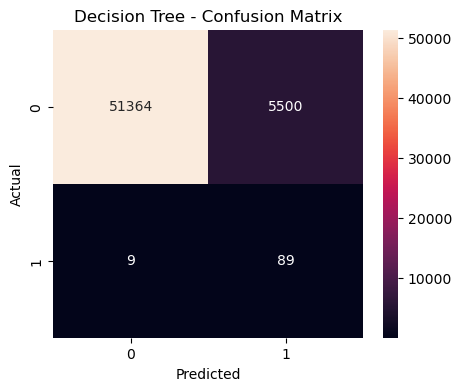

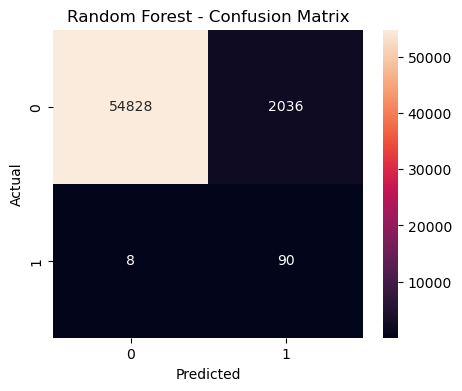

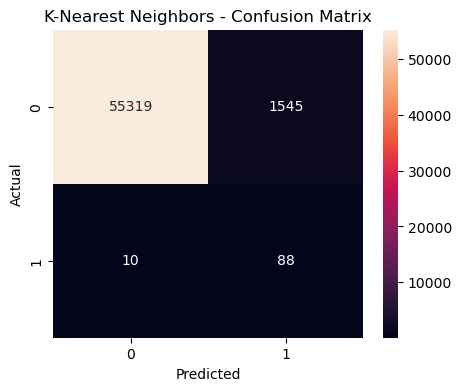

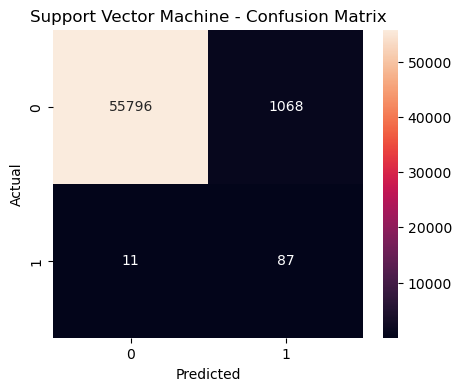

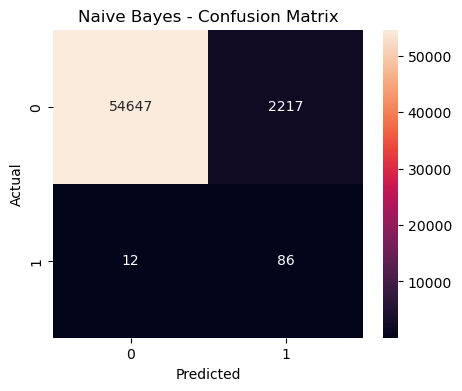

In [33]:
for name, model in trained_models.items():

    y_pred = model.predict(
        X_test_scaled
    )

    cm = confusion_matrix(
        y_test,
        y_pred
    )

    plt.figure(figsize=(5, 4))

    sns.heatmap(
        cm,
        annot=True,
        fmt="d"
    )

    plt.title(f"{name} - Confusion Matrix")
    plt.xlabel("Predicted")
    plt.ylabel("Actual")

    plt.show()

In [34]:
results_df.to_csv(
    "./results/baseline_results.csv",
    index=False
)

In [35]:
import joblib


for name, model in trained_models.items():

    filename = (
        name.lower()
        .replace(" ", "_")
        .replace("-", "_")
    )

    joblib.dump(
        model,
        f"./models/{filename}.pkl"
    )

# Baseline Model Analysis

Six baseline machine learning algorithms were trained:

1. Logistic Regression
2. Decision Tree
3. Random Forest
4. K-Nearest Neighbors
5. Support Vector Machine
6. Naive Bayes

The models were evaluated using:

- Accuracy
- Precision
- Recall
- F1-score
- ROC-AUC
- Confusion Matrix
- ROC Curve

The baseline results will be used as the reference point for the
next stage of the project.

The next stage will investigate whether hyperparameter tuning and
alternative imbalance-handling strategies can improve the models.